In [1]:
# Run this in a Jupyter cell (with ! prefix) or in your Ubuntu terminal
!pip install torch torchvision opencv-python matplotlib requests transformers
!pip install git+https://github.com/facebookresearch/segment-anything.git

# Download the SAM ViT-B model weights (lighter and faster for exploration)
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-00jj3o7p
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-00jj3o7p
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Loading SAM (ViT-B) model...
Model loaded on cuda.


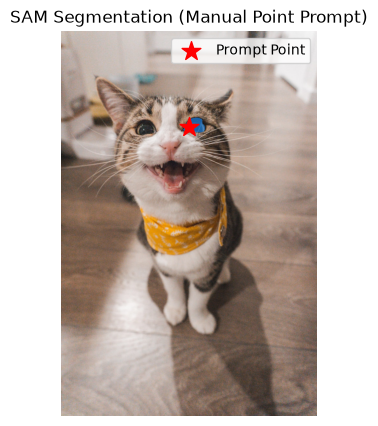

Result saved to: output_images/02_sam_manual_mask.png


In [2]:
# [Cell 1: Imports & Setup]
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

os.makedirs("output_images", exist_ok=True)
image_path = "input_images/sample_cat.jpg"

# [Cell 2: Load SAM Model]
print("Loading SAM (ViT-B) model...")
sam_checkpoint = "sam_vit_b_01ec64.pth"
model_type = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)
print(f"Model loaded on {device}.")

# [Cell 3: Generate Mask from Manual Point Prompt]
# Load image using OpenCV (BGR format) and convert to RGB
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Set the image in the predictor
predictor.set_image(image_rgb)

# Define a manual point (x, y) roughly on the cat's face
# Note: Coordinates depend on the image size. E.g., X:400, Y:300
input_point = np.array([[400, 300]])
input_label = np.array([1]) # 1 indicates foreground

# Predict the mask
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)

# Select the mask with the highest confidence score
best_mask = masks[np.argmax(scores)]

# Visualization function for the mask
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

# Plot and save
plt.figure(figsize=(10, 5))
plt.imshow(image_rgb)
show_mask(best_mask, plt.gca())
plt.scatter(input_point[:, 0], input_point[:, 1], color='red', marker='*', s=200, label="Prompt Point")
plt.title("SAM Segmentation (Manual Point Prompt)")
plt.axis("off")
plt.legend()

output_path = "output_images/02_sam_manual_mask.png"
plt.savefig(output_path, bbox_inches="tight")
plt.show()
print(f"Result saved to: {output_path}")